# 02 - Data Analysis

## AI & Social Media Impact: Student Health & Grades

This notebook performs the main analysis of the cleaned student dataset.

### Goals
- Understand the relationships between social media usage, AI usage, health, lifestyle, and academic performance.
- Compare important groups such as burnout levels and academic failure risk.
- Identify useful patterns and correlations.
- Summarize the main findings for later reporting and machine learning.

**Input:** `data/processed/AI_SocialMedia_Student_Health_Dataset_clean.csv`

## 1. Import Libraries

We import the libraries needed for data analysis and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display more columns when showing DataFrames.
pd.set_option("display.max_columns", None)

# Make plots easier to read.
sns.set_theme(style="whitegrid")

## 2. Load the Cleaned Dataset

The cleaning step already created the processed CSV file. We use that file for the analysis.

In [2]:
DATA_PATH = "../data/processed/AI_SocialMedia_Student_Health_Dataset_clean.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully: {DATA_PATH}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully: ../data/processed/AI_SocialMedia_Student_Health_Dataset_clean.csv
Rows: 15000
Columns: 14


## 3. Quick Dataset Overview

First, we check the structure of the cleaned dataset before starting the detailed analysis.

In [3]:
display(df.head())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

,Student_ID,Age,Gender,Education_Level,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score,Social_Isolation_Score,Burnout_Level,Academic_Performance_Score,Academic_Failure_Risk
0,STU_00001,19,Male,College,5.32,1.21,7.30,1.41,74.06,98.90,4.05,Low,88.80,0
1,STU_00002,16,Non-binary,High School,5.21,3.89,7.81,2.48,76.13,89.94,4.65,Moderate,50.60,0
2,STU_00003,25,Male,University,3.61,2.65,6.34,0.06,65.01,76.75,5.28,Low,96.67,0
3,STU_00004,23,Male,University,2.93,1.43,6.12,1.37,74.67,87.38,3.66,Low,85.65,0
4,STU_00005,20,Non-binary,College,6.52,1.64,5.23,1.14,67.74,88.04,3.25,Moderate,71.84,0



Data types:


,Data Type
Student_ID,str
Age,int64
Gender,str
Education_Level,str
Daily_Social_Media_Hours,float64
Daily_AI_Tool_Usage_Hours,float64
Sleep_Hours,float64
Physical_Activity_Hours,float64
Mental_Health_Score,float64
Physical_Health_Score,float64



Missing values: 0
Duplicate rows: 0


## 4. Separate Numerical and Categorical Columns

Separating the columns makes it easier to perform the correct type of analysis.

In [4]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical columns:")
for column in numerical_columns:
    print(f"- {column}")

print("\nCategorical columns:")
for column in categorical_columns:
    print(f"- {column}")

Numerical columns:
- Age
- Daily_Social_Media_Hours
- Daily_AI_Tool_Usage_Hours
- Sleep_Hours
- Physical_Activity_Hours
- Mental_Health_Score
- Physical_Health_Score
- Social_Isolation_Score
- Academic_Performance_Score
- Academic_Failure_Risk

Categorical columns:
- Student_ID
- Gender
- Education_Level
- Burnout_Level


C:\Users\ayman\AppData\Local\Temp\ipykernel_17644\3255864776.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()


## 5. Descriptive Statistics

These statistics help us understand the typical values and variation of the numerical variables.

In [5]:
summary = df[numerical_columns].describe().T
summary["median"] = df[numerical_columns].median()
summary["variance"] = df[numerical_columns].var()
summary["IQR"] = df[numerical_columns].quantile(0.75) - df[numerical_columns].quantile(0.25)

display(summary.round(2))

,count,mean,std,min,25%,50%,75%,max,median,variance,IQR
Age,15000.0,19.04,3.77,13.00,16.00,19.00,22.00,25.00,19.00,14.19,6.00
Daily_Social_Media_Hours,15000.0,4.54,2.40,0.00,2.83,4.50,6.18,14.00,4.50,5.75,3.35
Daily_AI_Tool_Usage_Hours,15000.0,2.58,1.68,0.00,1.31,2.51,3.74,9.50,2.51,2.82,2.43
Sleep_Hours,15000.0,6.54,1.27,2.00,5.68,6.55,7.41,11.15,6.55,1.61,1.73
Physical_Activity_Hours,15000.0,1.25,1.04,0.00,0.31,1.13,1.95,5.00,1.13,1.08,1.64
Mental_Health_Score,15000.0,72.51,9.25,32.56,66.78,73.76,79.58,91.76,73.76,85.48,12.80
Physical_Health_Score,15000.0,88.02,9.68,48.03,81.52,89.47,97.16,99.98,89.47,93.78,15.64
Social_Isolation_Score,15000.0,4.31,1.16,0.97,3.47,4.28,5.12,8.41,4.28,1.35,1.65
Academic_Performance_Score,15000.0,78.31,11.54,23.99,70.53,78.59,86.70,99.98,78.59,133.28,16.17
Academic_Failure_Risk,15000.0,0.06,0.24,0.00,0.00,0.00,0.00,1.00,0.00,0.06,0.00


## 6. Categorical Variables

We examine the number and percentage of students in each category.

In [6]:
for column in ["Gender", "Education_Level", "Burnout_Level"]:
    print("=" * 70)
    print(column)
    print("=" * 70)
    
    counts = df[column].value_counts()
    percentages = df[column].value_counts(normalize=True).mul(100)
    
    result = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages.round(2)
    })
    
    display(result)

Gender


,Count,Percentage
Gender,,
Male,7265,48.43
Female,7143,47.62
Non-binary,592,3.95


Education_Level


,Count,Percentage
Education_Level,,
High School,5693,37.95
University,4710,31.40
College,4597,30.65


Burnout_Level


,Count,Percentage
Burnout_Level,,
Low,9000,60.0
Moderate,4200,28.0
High,1350,9.0
Severe,450,3.0


## 7. Target Variable: Academic Failure Risk

`Academic_Failure_Risk` is the main target variable for the project.

- `0` = No academic failure risk
- `1` = Academic failure risk

We first check how balanced the two classes are.

,Count,Percentage
Academic_Failure_Risk,,
0,14100,94.0
1,900,6.0


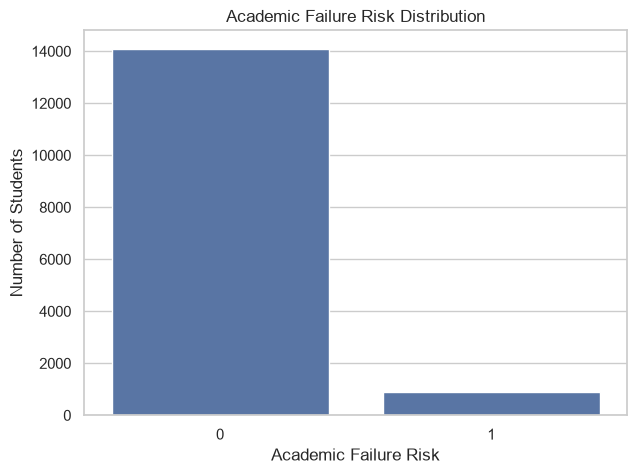

In [7]:
target_counts = df["Academic_Failure_Risk"].value_counts().sort_index()
target_percentages = df["Academic_Failure_Risk"].value_counts(normalize=True).sort_index().mul(100)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

display(target_summary)

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Academic_Failure_Risk")
plt.title("Academic Failure Risk Distribution")
plt.xlabel("Academic Failure Risk")
plt.ylabel("Number of Students")
plt.show()

## 8. Correlation Analysis

Correlation shows how strongly two numerical variables move together.

- Positive correlation: both variables tend to increase together.
- Negative correlation: one variable tends to increase while the other decreases.
- Values close to 0 indicate a weak linear relationship.

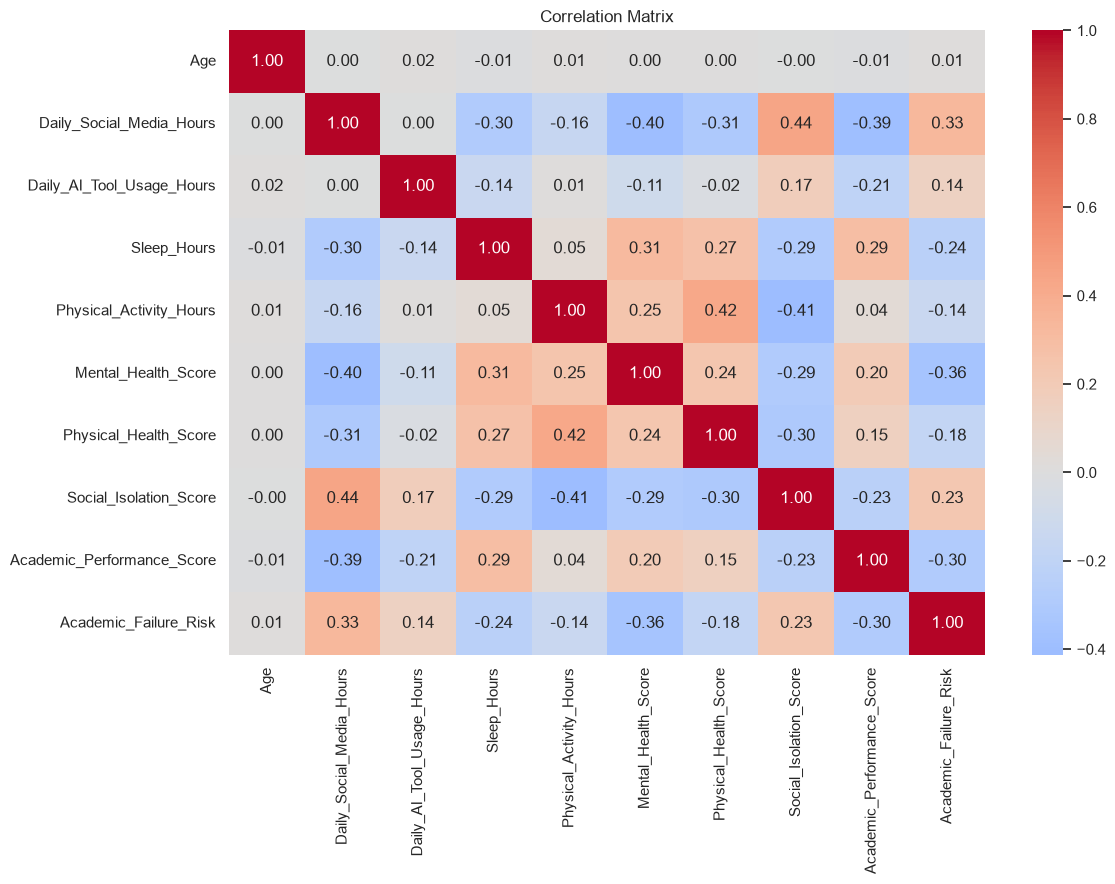

In [8]:
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 9. Strongest Relationships with Academic Performance

Academic performance is one of the most important outcomes in this dataset. We rank the correlations with `Academic_Performance_Score`.

In [9]:
academic_correlations = (
    correlation_matrix["Academic_Performance_Score"]
    .drop("Academic_Performance_Score")
    .sort_values(key=abs, ascending=False)
)

display(academic_correlations.to_frame("Correlation with Academic Performance").round(3))

,Correlation with Academic Performance
Daily_Social_Media_Hours,-0.394
Academic_Failure_Risk,-0.296
Sleep_Hours,0.292
Social_Isolation_Score,-0.235
Daily_AI_Tool_Usage_Hours,-0.205
Mental_Health_Score,0.204
Physical_Health_Score,0.151
Physical_Activity_Hours,0.042
Age,-0.008


## 10. Social Media Usage and Academic Performance

We investigate whether daily social media usage is associated with academic performance.

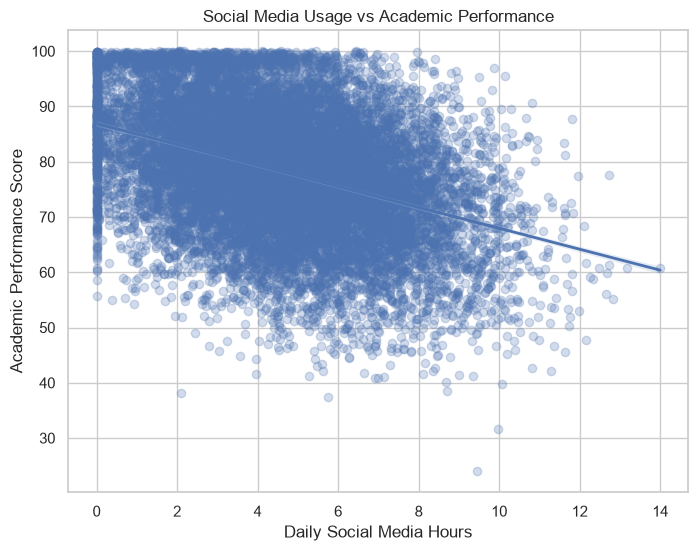

Correlation: -0.394


In [10]:
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df,
    x="Daily_Social_Media_Hours",
    y="Academic_Performance_Score",
    scatter_kws={"alpha": 0.25},
    line_kws={"linewidth": 2}
)
plt.title("Social Media Usage vs Academic Performance")
plt.xlabel("Daily Social Media Hours")
plt.ylabel("Academic Performance Score")
plt.show()

social_corr = df["Daily_Social_Media_Hours"].corr(df["Academic_Performance_Score"])
print(f"Correlation: {social_corr:.3f}")

## 11. Social Media Usage and Academic Failure Risk

Now we compare social media usage between students with and without academic failure risk.

,count,mean,median,min,max
Academic_Failure_Risk,,,,,
0,14100,4.34,4.33,0.0,12.73
1,900,7.67,7.60,1.7,14.00


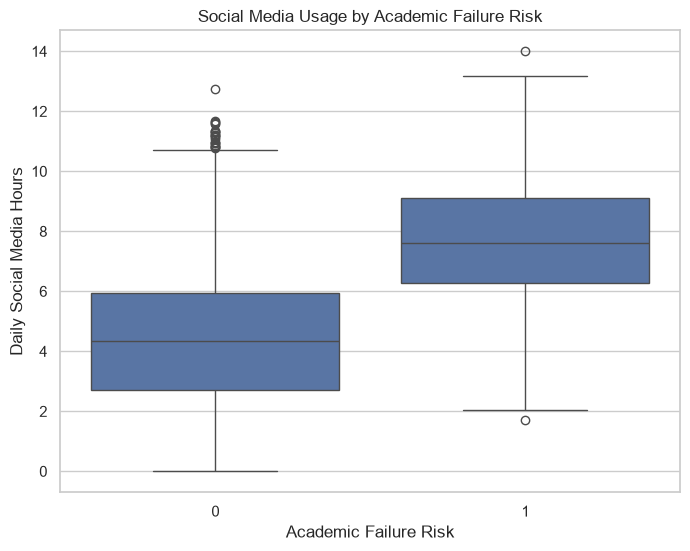

In [11]:
social_risk_summary = df.groupby("Academic_Failure_Risk")[
    "Daily_Social_Media_Hours"
].agg(["count", "mean", "median", "min", "max"])

display(social_risk_summary.round(2))

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x="Academic_Failure_Risk",
    y="Daily_Social_Media_Hours"
)
plt.title("Social Media Usage by Academic Failure Risk")
plt.xlabel("Academic Failure Risk")
plt.ylabel("Daily Social Media Hours")
plt.show()

## 12. AI Tool Usage and Academic Performance

We examine the relationship between daily AI tool usage and academic performance.

Correlation between AI usage and academic performance: -0.205


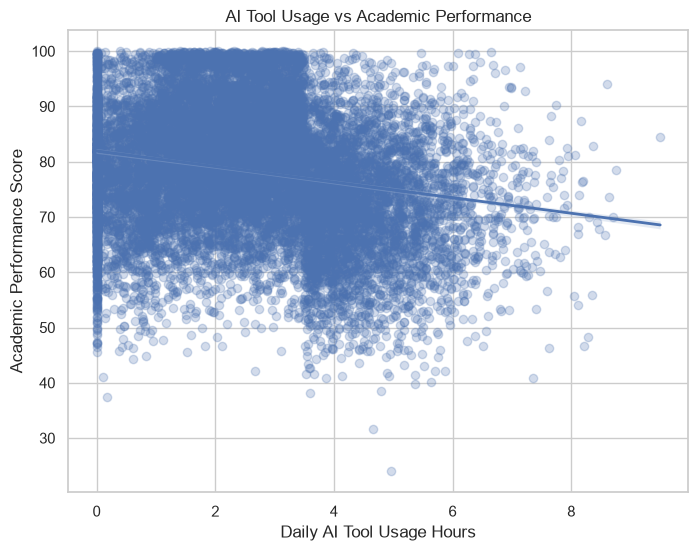

In [12]:
ai_corr = df["Daily_AI_Tool_Usage_Hours"].corr(df["Academic_Performance_Score"])
print(f"Correlation between AI usage and academic performance: {ai_corr:.3f}")

plt.figure(figsize=(8, 6))
sns.regplot(
    data=df,
    x="Daily_AI_Tool_Usage_Hours",
    y="Academic_Performance_Score",
    scatter_kws={"alpha": 0.25},
    line_kws={"linewidth": 2}
)
plt.title("AI Tool Usage vs Academic Performance")
plt.xlabel("Daily AI Tool Usage Hours")
plt.ylabel("Academic Performance Score")
plt.show()

## 13. Sleep and Academic Performance

Sleep is an important lifestyle factor. We check its relationship with academic performance.

Correlation between sleep and academic performance: 0.292


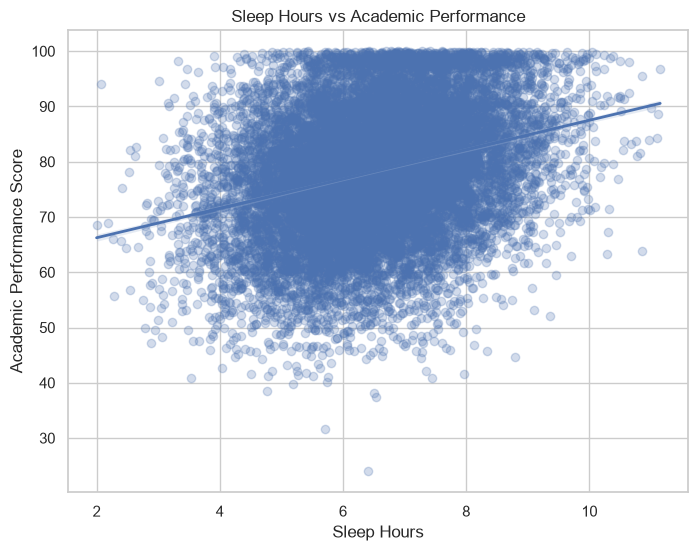

In [13]:
sleep_corr = df["Sleep_Hours"].corr(df["Academic_Performance_Score"])
print(f"Correlation between sleep and academic performance: {sleep_corr:.3f}")

plt.figure(figsize=(8, 6))
sns.regplot(
    data=df,
    x="Sleep_Hours",
    y="Academic_Performance_Score",
    scatter_kws={"alpha": 0.25},
    line_kws={"linewidth": 2}
)
plt.title("Sleep Hours vs Academic Performance")
plt.xlabel("Sleep Hours")
plt.ylabel("Academic Performance Score")
plt.show()

## 14. Mental Health and Academic Performance

We investigate whether mental health scores are associated with academic performance.

Correlation between mental health and academic performance: 0.204


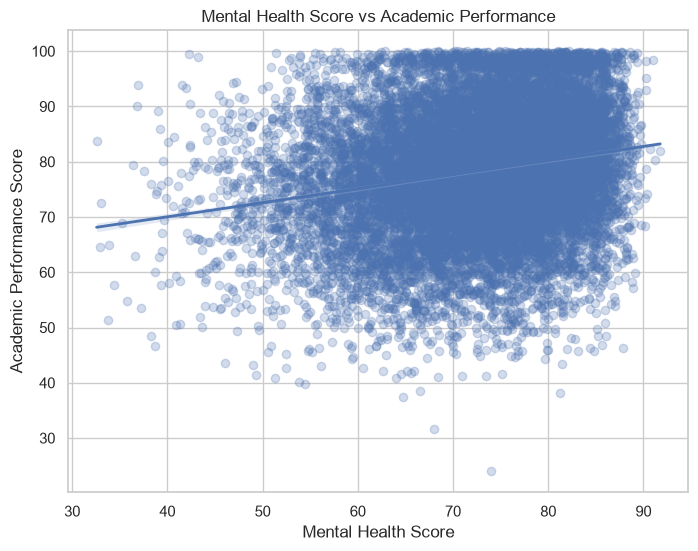

In [14]:
mental_corr = df["Mental_Health_Score"].corr(df["Academic_Performance_Score"])
print(f"Correlation between mental health and academic performance: {mental_corr:.3f}")

plt.figure(figsize=(8, 6))
sns.regplot(
    data=df,
    x="Mental_Health_Score",
    y="Academic_Performance_Score",
    scatter_kws={"alpha": 0.25},
    line_kws={"linewidth": 2}
)
plt.title("Mental Health Score vs Academic Performance")
plt.xlabel("Mental Health Score")
plt.ylabel("Academic Performance Score")
plt.show()

## 15. Physical Health and Academic Performance

We compare physical health scores with academic performance.

Correlation between physical health and academic performance: 0.151


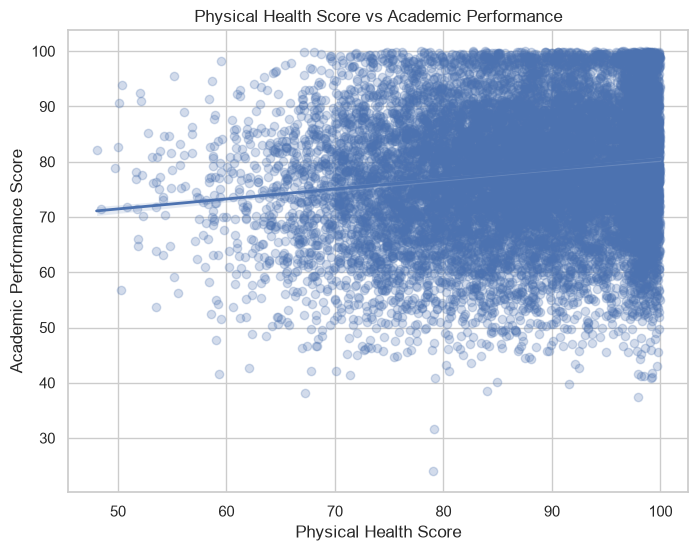

In [15]:
physical_corr = df["Physical_Health_Score"].corr(df["Academic_Performance_Score"])
print(f"Correlation between physical health and academic performance: {physical_corr:.3f}")

plt.figure(figsize=(8, 6))
sns.regplot(
    data=df,
    x="Physical_Health_Score",
    y="Academic_Performance_Score",
    scatter_kws={"alpha": 0.25},
    line_kws={"linewidth": 2}
)
plt.title("Physical Health Score vs Academic Performance")
plt.xlabel("Physical Health Score")
plt.ylabel("Academic Performance Score")
plt.show()

## 16. Physical Activity and Academic Performance

We check whether physical activity has a noticeable relationship with academic performance.

Correlation between physical activity and academic performance: 0.042


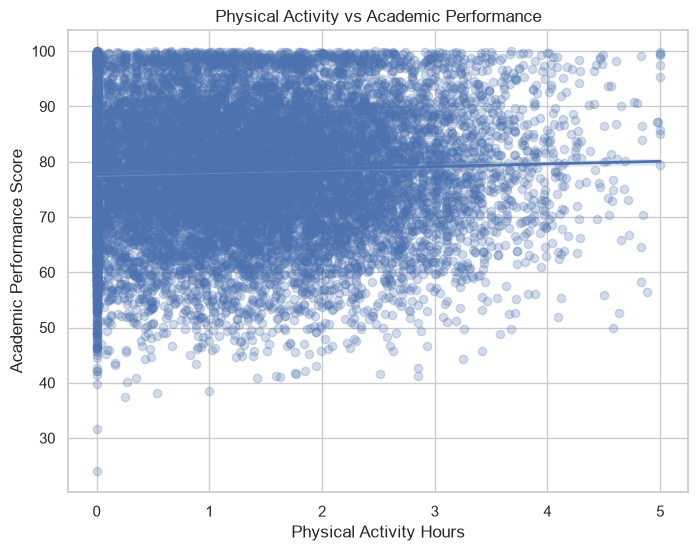

In [16]:
activity_corr = df["Physical_Activity_Hours"].corr(df["Academic_Performance_Score"])
print(f"Correlation between physical activity and academic performance: {activity_corr:.3f}")

plt.figure(figsize=(8, 6))
sns.regplot(
    data=df,
    x="Physical_Activity_Hours",
    y="Academic_Performance_Score",
    scatter_kws={"alpha": 0.25},
    line_kws={"linewidth": 2}
)
plt.title("Physical Activity vs Academic Performance")
plt.xlabel("Physical Activity Hours")
plt.ylabel("Academic Performance Score")
plt.show()

## 17. Social Isolation and Academic Performance

We examine whether social isolation is associated with academic performance.

Correlation between social isolation and academic performance: -0.235


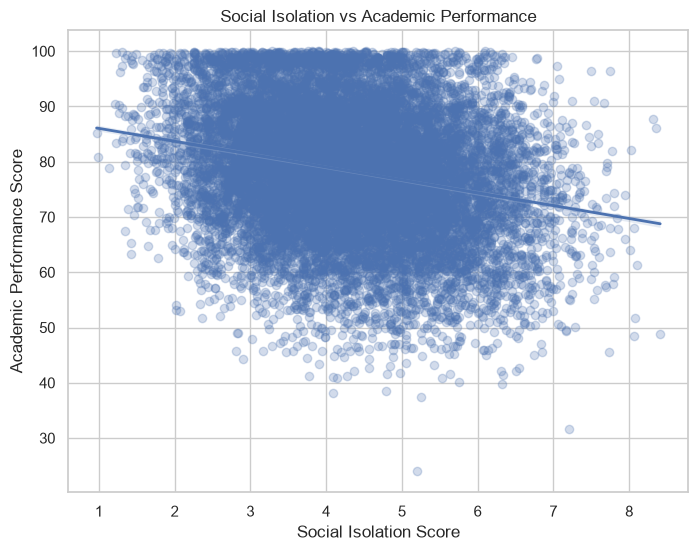

In [17]:
isolation_corr = df["Social_Isolation_Score"].corr(df["Academic_Performance_Score"])
print(f"Correlation between social isolation and academic performance: {isolation_corr:.3f}")

plt.figure(figsize=(8, 6))
sns.regplot(
    data=df,
    x="Social_Isolation_Score",
    y="Academic_Performance_Score",
    scatter_kws={"alpha": 0.25},
    line_kws={"linewidth": 2}
)
plt.title("Social Isolation vs Academic Performance")
plt.xlabel("Social Isolation Score")
plt.ylabel("Academic Performance Score")
plt.show()

## 18. Burnout Level and Academic Performance

Burnout is divided into four levels: Low, Moderate, High, and Severe. We compare academic performance across these groups.

,count,mean,median,std,min,max
Burnout_Level,,,,,,
Low,9000,80.86,81.26,10.88,38.19,99.97
Moderate,4200,75.79,75.77,11.22,37.36,99.98
High,1350,72.44,72.63,11.31,23.99,99.34
Severe,450,68.64,69.04,11.55,40.08,99.48


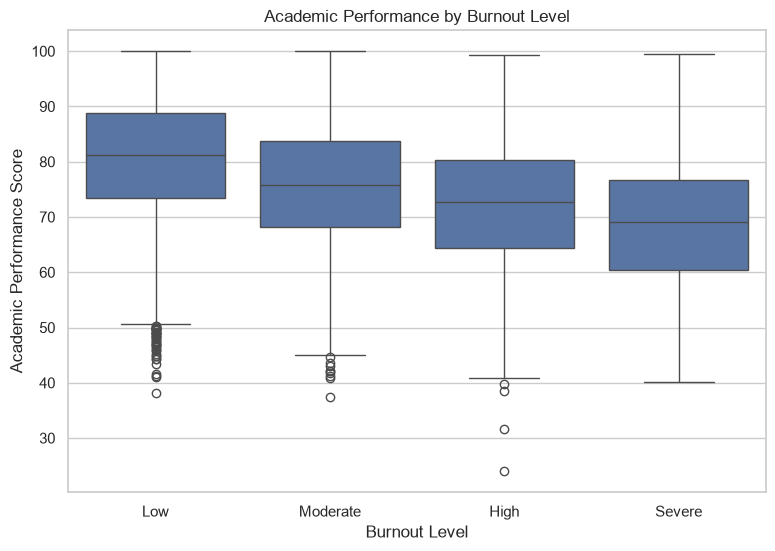

In [18]:
burnout_order = ["Low", "Moderate", "High", "Severe"]

burnout_performance = df.groupby("Burnout_Level")[
    "Academic_Performance_Score"
].agg(["count", "mean", "median", "std", "min", "max"]).reindex(burnout_order)

display(burnout_performance.round(2))

plt.figure(figsize=(9, 6))
sns.boxplot(
    data=df,
    x="Burnout_Level",
    y="Academic_Performance_Score",
    order=burnout_order
)
plt.title("Academic Performance by Burnout Level")
plt.xlabel("Burnout Level")
plt.ylabel("Academic Performance Score")
plt.show()

## 19. Burnout Level and Academic Failure Risk

We calculate the percentage of students at academic failure risk within each burnout group.

,No Risk (%),Failure Risk (%)
Burnout_Level,,
Low,100.00,0.00
Moderate,100.00,0.00
High,66.67,33.33
Severe,0.00,100.00


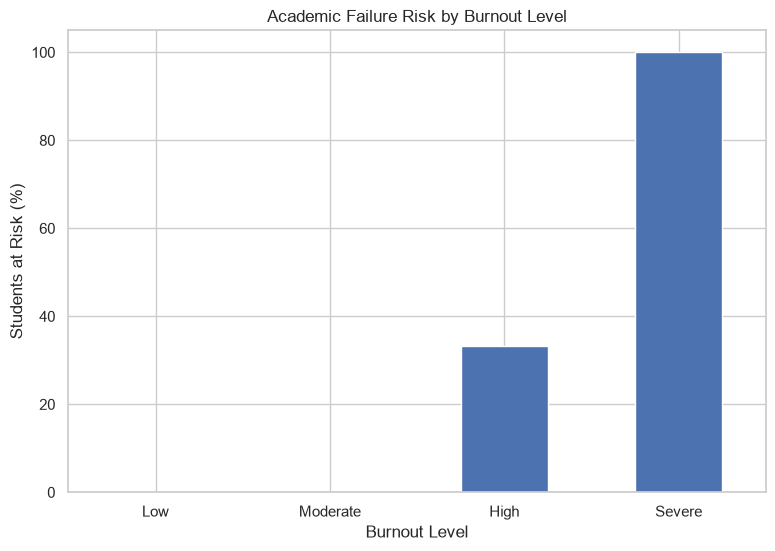

In [19]:
burnout_risk = pd.crosstab(
    df["Burnout_Level"],
    df["Academic_Failure_Risk"],
    normalize="index"
).mul(100).reindex(burnout_order)

burnout_risk.columns = ["No Risk (%)", "Failure Risk (%)"]

display(burnout_risk.round(2))

burnout_risk["Failure Risk (%)"].plot(kind="bar", figsize=(9, 6))
plt.title("Academic Failure Risk by Burnout Level")
plt.xlabel("Burnout Level")
plt.ylabel("Students at Risk (%)")
plt.xticks(rotation=0)
plt.show()

## 20. Gender and Academic Performance

We compare average academic performance across gender groups.

,count,mean,median,std
Gender,,,,
Female,7143,78.45,78.77,11.60
Male,7265,78.20,78.46,11.49
Non-binary,592,78.07,78.17,11.56


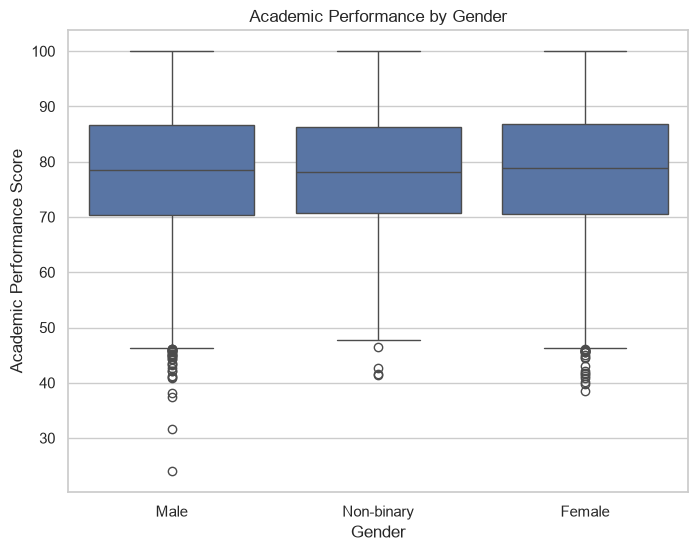

In [20]:
gender_analysis = df.groupby("Gender")[
    "Academic_Performance_Score"
].agg(["count", "mean", "median", "std"]).sort_values("mean", ascending=False)

display(gender_analysis.round(2))

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Gender", y="Academic_Performance_Score")
plt.title("Academic Performance by Gender")
plt.xlabel("Gender")
plt.ylabel("Academic Performance Score")
plt.show()

## 21. Education Level and Academic Performance

We compare academic performance among High School, College, and University students.

,count,mean,median,std
Education_Level,,,,
High School,5693,78.46,78.80,11.46
College,4597,78.31,78.70,11.57
University,4710,78.14,78.26,11.62


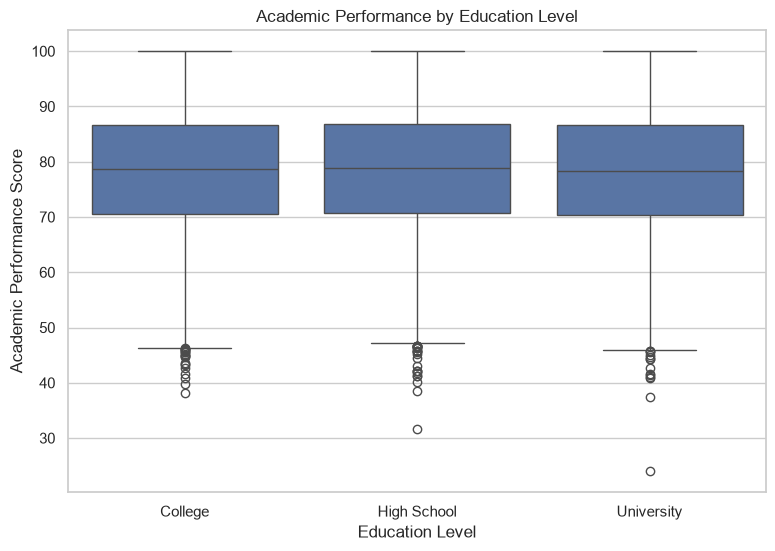

In [21]:
education_analysis = df.groupby("Education_Level")[
    "Academic_Performance_Score"
].agg(["count", "mean", "median", "std"]).sort_values("mean", ascending=False)

display(education_analysis.round(2))

plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x="Education_Level", y="Academic_Performance_Score")
plt.title("Academic Performance by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Academic Performance Score")
plt.show()

## 22. Group Analysis: Social Media Usage and Burnout

We compare average social media usage across burnout levels.

,count,mean,median,std
Burnout_Level,,,,
Low,9000,3.55,3.53,2.04
Moderate,4200,5.54,5.56,2.00
High,1350,6.80,6.81,1.84
Severe,450,8.14,8.22,1.95


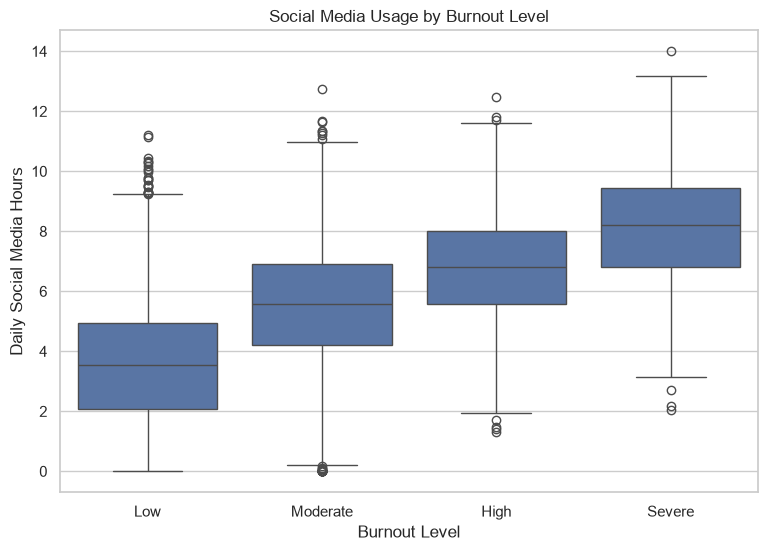

In [22]:
burnout_social = df.groupby("Burnout_Level")[
    "Daily_Social_Media_Hours"
].agg(["count", "mean", "median", "std"]).reindex(burnout_order)

display(burnout_social.round(2))

plt.figure(figsize=(9, 6))
sns.boxplot(
    data=df,
    x="Burnout_Level",
    y="Daily_Social_Media_Hours",
    order=burnout_order
)
plt.title("Social Media Usage by Burnout Level")
plt.xlabel("Burnout Level")
plt.ylabel("Daily Social Media Hours")
plt.show()

## 23. Group Analysis: Sleep and Burnout

We compare average sleep hours across burnout levels.

,count,mean,median,std
Burnout_Level,,,,
Low,9000,6.91,6.90,1.19
Moderate,4200,6.17,6.18,1.14
High,1350,5.67,5.65,1.13
Severe,450,5.24,5.24,1.07


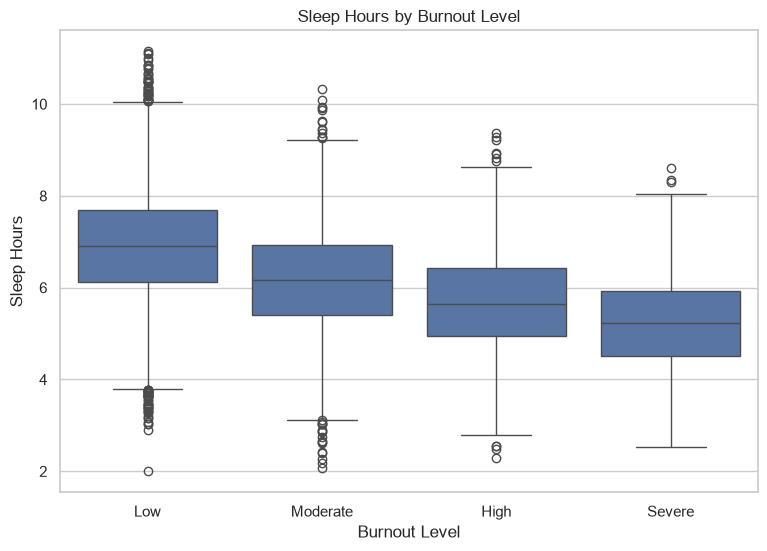

In [23]:
burnout_sleep = df.groupby("Burnout_Level")[
    "Sleep_Hours"
].agg(["count", "mean", "median", "std"]).reindex(burnout_order)

display(burnout_sleep.round(2))

plt.figure(figsize=(9, 6))
sns.boxplot(
    data=df,
    x="Burnout_Level",
    y="Sleep_Hours",
    order=burnout_order
)
plt.title("Sleep Hours by Burnout Level")
plt.xlabel("Burnout Level")
plt.ylabel("Sleep Hours")
plt.show()

## 24. Group Analysis: Mental Health and Burnout

We compare mental health scores across burnout groups.

,count,mean,median,std
Burnout_Level,,,,
Low,9000,76.01,77.09,7.41
Moderate,4200,69.16,69.94,8.50
High,1350,64.27,64.72,9.17
Severe,450,58.62,58.59,8.96


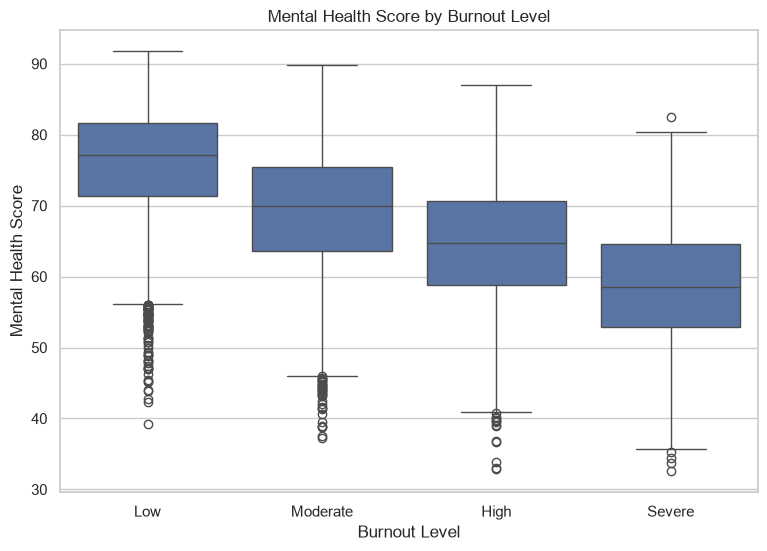

In [24]:
burnout_mental = df.groupby("Burnout_Level")[
    "Mental_Health_Score"
].agg(["count", "mean", "median", "std"]).reindex(burnout_order)

display(burnout_mental.round(2))

plt.figure(figsize=(9, 6))
sns.boxplot(
    data=df,
    x="Burnout_Level",
    y="Mental_Health_Score",
    order=burnout_order
)
plt.title("Mental Health Score by Burnout Level")
plt.xlabel("Burnout Level")
plt.ylabel("Mental Health Score")
plt.show()

## 25. Factors Associated with Academic Failure Risk

This table ranks numerical variables by their correlation with the target variable `Academic_Failure_Risk`.

In [25]:
risk_correlations = (
    correlation_matrix["Academic_Failure_Risk"]
    .drop("Academic_Failure_Risk")
    .sort_values(key=abs, ascending=False)
)

display(
    risk_correlations
    .to_frame("Correlation with Failure Risk")
    .round(3)
)

,Correlation with Failure Risk
Mental_Health_Score,-0.356
Daily_Social_Media_Hours,0.330
Academic_Performance_Score,-0.296
Sleep_Hours,-0.238
Social_Isolation_Score,0.231
Physical_Health_Score,-0.182
Daily_AI_Tool_Usage_Hours,0.139
Physical_Activity_Hours,-0.137
Age,0.011


## 26. Compare Students With and Without Failure Risk

Here we compare the average values of important variables for the two target groups.

In [26]:
important_columns = [
    "Daily_Social_Media_Hours",
    "Daily_AI_Tool_Usage_Hours",
    "Sleep_Hours",
    "Physical_Activity_Hours",
    "Mental_Health_Score",
    "Physical_Health_Score",
    "Social_Isolation_Score",
    "Academic_Performance_Score"
]

risk_group_means = df.groupby("Academic_Failure_Risk")[important_columns].mean().T
risk_group_means.columns = ["No Failure Risk", "Failure Risk"]

display(risk_group_means.round(2))

,No Failure Risk,Failure Risk
Daily_Social_Media_Hours,4.34,7.67
Daily_AI_Tool_Usage_Hours,2.53,3.51
Sleep_Hours,6.62,5.35
Physical_Activity_Hours,1.28,0.68
Mental_Health_Score,73.34,59.49
Physical_Health_Score,88.46,81.05
Social_Isolation_Score,4.24,5.37
Academic_Performance_Score,79.18,64.79


## 27. Create Useful Analysis Tables

These tables can be reused later in the project documentation or report.

In [27]:
# Average academic performance by burnout level.
burnout_summary = df.groupby("Burnout_Level").agg(
    Students=("Student_ID", "count"),
    Average_Performance=("Academic_Performance_Score", "mean"),
    Average_Social_Media=("Daily_Social_Media_Hours", "mean"),
    Average_AI_Usage=("Daily_AI_Tool_Usage_Hours", "mean"),
    Average_Sleep=("Sleep_Hours", "mean"),
    Average_Mental_Health=("Mental_Health_Score", "mean")
).reindex(burnout_order)

display(burnout_summary.round(2))

,Students,Average_Performance,Average_Social_Media,Average_AI_Usage,Average_Sleep,Average_Mental_Health
Burnout_Level,,,,,,
Low,9000,80.86,3.55,2.34,6.91,76.01
Moderate,4200,75.79,5.54,2.82,6.17,69.16
High,1350,72.44,6.80,3.20,5.67,64.27
Severe,450,68.64,8.14,3.38,5.24,58.62


## 28. Key Findings

The following cell automatically calculates a few important values that can be used when writing the project conclusions.

> Important: Correlation shows association, not causation. A relationship between two variables does not prove that one variable causes the other.

In [28]:
print("=" * 80)
print("KEY FINDINGS")
print("=" * 80)

social_corr = df["Daily_Social_Media_Hours"].corr(df["Academic_Performance_Score"])
ai_corr = df["Daily_AI_Tool_Usage_Hours"].corr(df["Academic_Performance_Score"])
sleep_corr = df["Sleep_Hours"].corr(df["Academic_Performance_Score"])
mental_corr = df["Mental_Health_Score"].corr(df["Academic_Performance_Score"])
risk_corr = risk_correlations.iloc[0]

print(f"\n1. Social media vs academic performance: {social_corr:.3f}")
print(f"2. AI usage vs academic performance: {ai_corr:.3f}")
print(f"3. Sleep vs academic performance: {sleep_corr:.3f}")
print(f"4. Mental health vs academic performance: {mental_corr:.3f}")
print(f"5. Strongest numerical correlation with failure risk: {risk_correlations.index[0]} ({risk_corr:.3f})")

highest_burnout_performance = burnout_performance["mean"].idxmax()
lowest_burnout_performance = burnout_performance["mean"].idxmin()

print(f"6. Highest average academic performance by burnout level: {highest_burnout_performance}")
print(f"7. Lowest average academic performance by burnout level: {lowest_burnout_performance}")

print("\nRemember: these results describe patterns in this dataset and should not be interpreted as proof of causation.")

KEY FINDINGS

1. Social media vs academic performance: -0.394
2. AI usage vs academic performance: -0.205
3. Sleep vs academic performance: 0.292
4. Mental health vs academic performance: 0.204
5. Strongest numerical correlation with failure risk: Mental_Health_Score (-0.356)
6. Highest average academic performance by burnout level: Low
7. Lowest average academic performance by burnout level: Severe

Remember: these results describe patterns in this dataset and should not be interpreted as proof of causation.


## 29. Conclusion

### What We Analyzed

This notebook examined the main relationships in the cleaned student dataset, including:

- Social media usage and academic performance.
- AI tool usage and academic performance.
- Sleep, physical activity, and health indicators.
- Burnout levels and academic outcomes.
- Demographic and education-level differences.
- Factors associated with academic failure risk.

### Next Step

The next stage can use these findings to prepare the dataset for **machine learning**, where `Academic_Failure_Risk` can be used as the target variable for classification models.